<a href="https://colab.research.google.com/github/Tahsinefeodabasi/-i-ek/blob/main/customeranalys.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install streamlit -q
!npm install -g localtunnel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 68.5 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹
added 22 packages in 3s
⠹
⠹3 packages are looking for funding
⠹  run `npm fund` for details
⠹

In [31]:
import pandas as pd
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [32]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [33]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [34]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [35]:
df.drop('customerID', axis=1, inplace=True)

In [36]:
print("\nTemizlik sonrası TotalCharges tipi:", df['TotalCharges'].dtype)



Temizlik sonrası TotalCharges tipi: float64


/tmp/ipykernel_7275/751703427.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


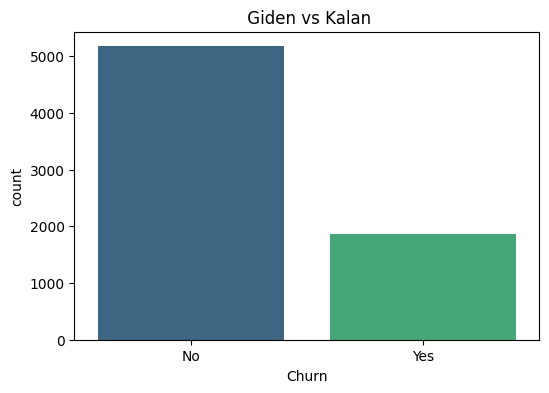

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [37]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title(' Giden vs Kalan')
plt.show()
print(df['Churn'].value_counts(normalize=True))

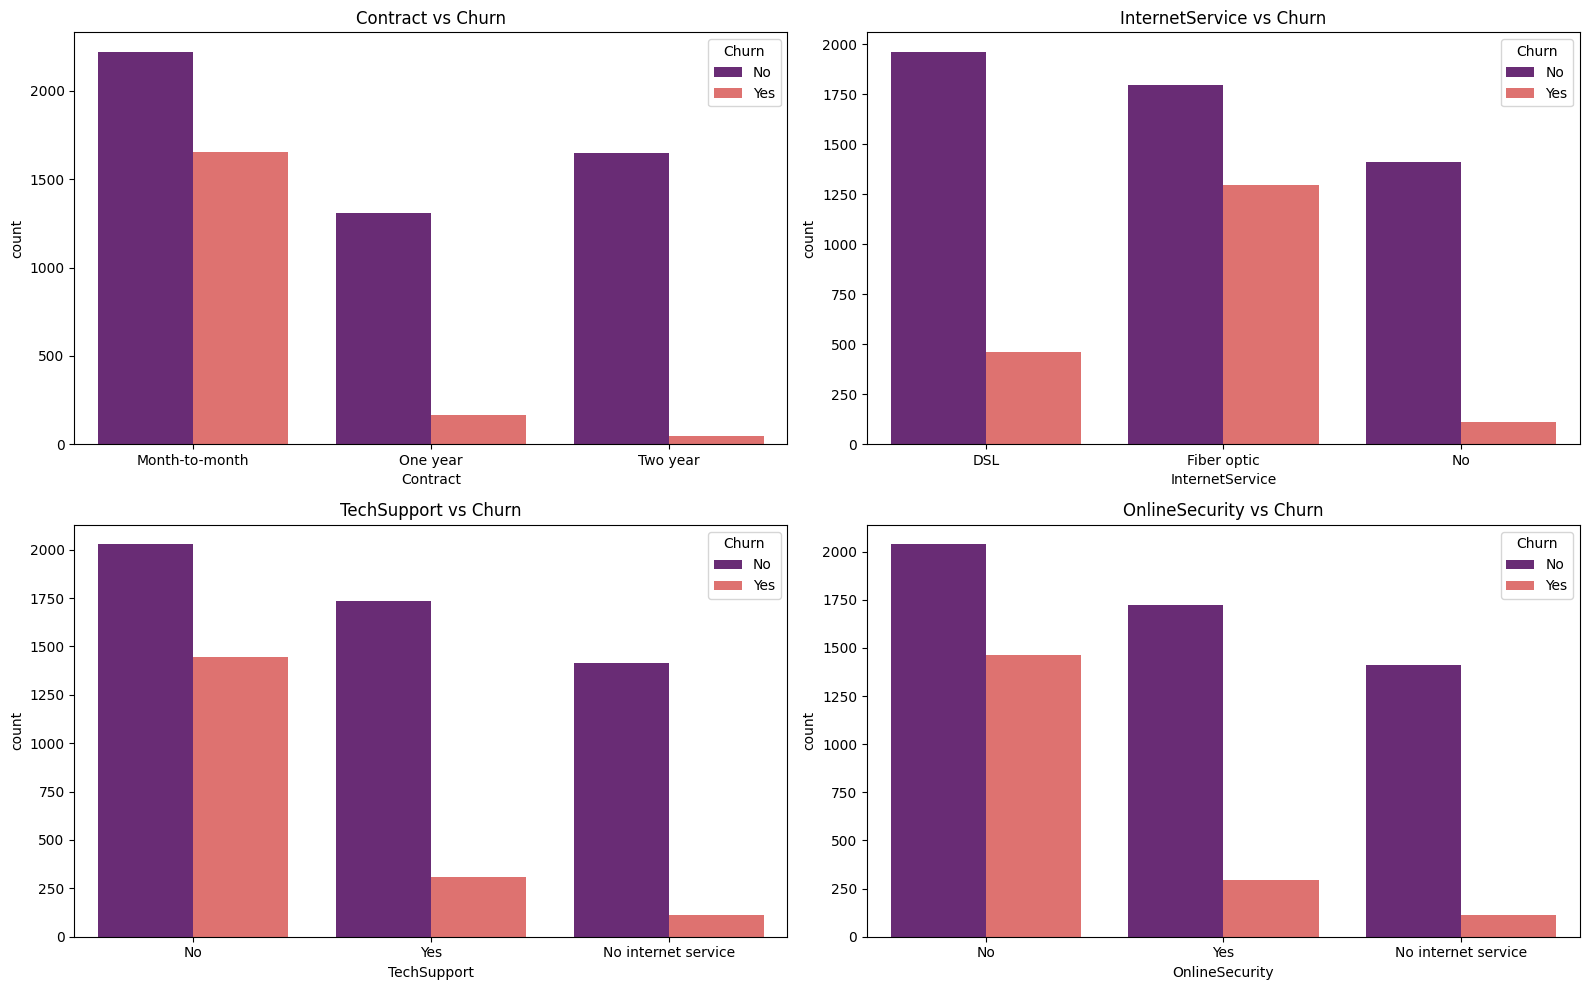

In [38]:

features = ['Contract', 'InternetService', 'TechSupport', 'OnlineSecurity']

plt.figure(figsize=(16, 10))

for i, feature in enumerate(features):
    plt.subplot(2, 2, i+1)
    sns.countplot(x=feature, hue='Churn', data=df, palette='magma')
    plt.title(f'{feature} vs Churn')

plt.tight_layout()
plt.show()

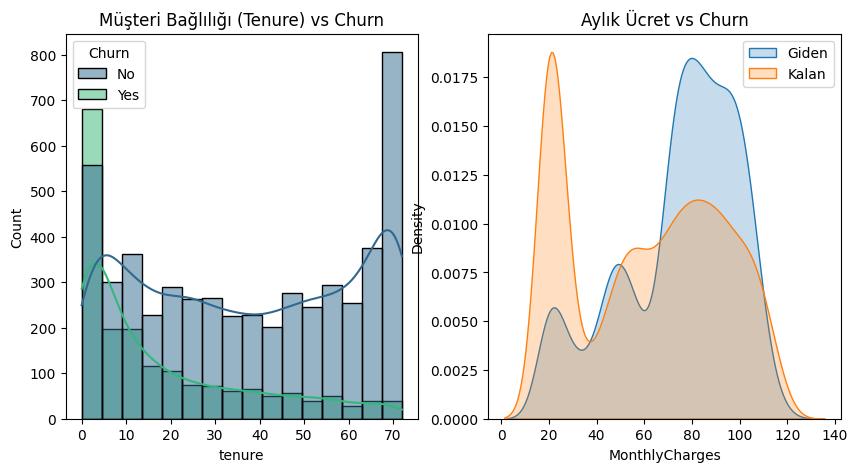

In [39]:
plt.figure(figsize=(10, 5))


plt.subplot(1, 2, 1)
sns.histplot(x='tenure', hue='Churn', data=df, kde=True, palette='viridis')
plt.title('Müşteri Bağlılığı (Tenure) vs Churn')

plt.subplot(1, 2, 2)
sns.kdeplot(df[df['Churn'] == 'Yes']['MonthlyCharges'], label='Giden', fill=True)
sns.kdeplot(df[df['Churn'] == 'No']['MonthlyCharges'], label='Kalan', fill=True)
plt.title('Aylık Ücret vs Churn')
plt.legend()

plt.show()

In [40]:

df['Churn'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

df_final = pd.get_dummies(df)

print(df_final.head())
print("\nYeni sütun sayısı:", df_final.shape[1])

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Female  \
0              0       1           29.85         29.85      0           True   
1              0      34           56.95       1889.50      0          False   
2              0       2           53.85        108.15      1          False   
3              0      45           42.30       1840.75      0          False   
4              0       2           70.70        151.65      1           True   

   gender_Male  Partner_No  Partner_Yes  Dependents_No  ...  \
0        False       False         True           True  ...   
1         True        True        False           True  ...   
2         True        True        False           True  ...   
3         True        True        False           True  ...   
4        False        True        False           True  ...   

   StreamingMovies_Yes  Contract_Month-to-month  Contract_One year  \
0                False                     True              False   


In [41]:
from sklearn.model_selection import train_test_split

# X: Girdi değişkenleri (Churn hariç her şey)
# y: Hedef değişken (Sadece Churn sütunu)
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']

# Veriyi %80 Eğitim, %20 Test olarak bölelim
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Eğitim seti boyutu: {X_train.shape}")
print(f"Test seti boyutu: {X_test.shape}")

Eğitim seti boyutu: (5634, 45)
Test seti boyutu: (1409, 45)


In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Modeli Tanımla (Random Forest)
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Modeli Eğit (Eğitim verilerini modele veriyoruz)
model.fit(X_train, y_train)

# 3. Tahmin Yap (Modelin hiç görmediği test verilerini soruyoruz)
y_pred = model.predict(X_test)

# 4. Sonuçları Değerlendir
print("--- Model Performansı ---")
print(f"Doğruluk (Accuracy) Skoru: {accuracy_score(y_test, y_pred):.2f}")
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred))

--- Model Performansı ---
Doğruluk (Accuracy) Skoru: 0.80

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.48      0.55       373

    accuracy                           0.80      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409



/tmp/ipykernel_7275/2133392864.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Önem', y='Özellik', data=feature_importance_df.head(10), palette='coolwarm')


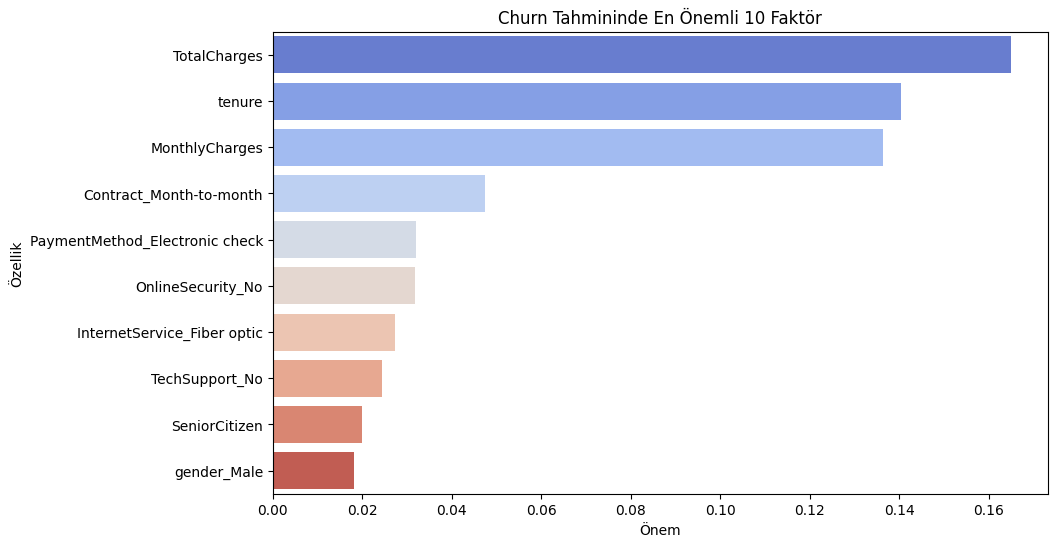

In [43]:
# Özelliklerin önem sırasını alalım
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Özellik': feature_names, 'Önem': importances}).sort_values(by='Önem', ascending=False)

# İlk 10 önemli özelliği görselleştirelim
plt.figure(figsize=(10, 6))
sns.barplot(x='Önem', y='Özellik', data=feature_importance_df.head(10), palette='coolwarm')
plt.title('Churn Tahmininde En Önemli 10 Faktör')
plt.show()

In [44]:
import pickle

# Modeli kaydet
with open('churn_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Eğitim setindeki sütun isimlerini de kaydedelim (Arayüzde girdi alırken sırayı bozmamak için kritik!)
model_columns = list(X.columns)
with open('model_columns.pkl', 'wb') as f:
    pickle.dump(model_columns, f)

print("Model ve sütunlar başarıyla paketlendi!")

Model ve sütunlar başarıyla paketlendi!


In [46]:
%%writefile app.py
import streamlit as st
import pandas as pd
import pickle

# Modeli ve sütunları yükle
model = pickle.load(open('churn_model.pkl', 'rb'))
model_columns = pickle.load(open('model_columns.pkl', 'rb'))

st.title("📱 Turkcell GNÇYTNK - Churn Tahmin Paneli")

# Sidebar girişleri
tenure = st.sidebar.slider("Tenure (Ay)", 0, 72, 12)
monthly_charges = st.sidebar.number_input("Aylık Fatura ($)", 0, 150, 70)
contract = st.sidebar.selectbox("Sözleşme", ["Month-to-month", "One year", "Two year"])
internet_service = st.sidebar.selectbox("İnternet", ["Fiber optic", "DSL", "No"])

if st.button("Analiz Et"):
    input_data = pd.DataFrame(0, index=[0], columns=model_columns)
    input_data['tenure'] = tenure
    input_data['MonthlyCharges'] = monthly_charges

    # Kategori eşleştirme
    if f'Contract_{contract}' in model_columns:
        input_data[f'Contract_{contract}'] = 1
    if f'InternetService_{internet_service}' in model_columns:
        input_data[f'InternetService_{internet_service}'] = 1

    prob = model.predict_proba(input_data)[0][1]

    if prob > 0.5:
        st.error(f"⚠️ Risk Yüksek: %{prob*100:.1f}")
    else:
        st.success(f"✅ Risk Düşük: %{prob*100:.1f}")

Writing app.py


In [47]:
!wget -q -O - ipv4.icanhazip.com

34.135.114.204


In [49]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹

⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧your url is: https://tasty-trees-flash.loca.lt

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.135.114.204:8501

  Stopping...
^C
